<a href="https://colab.research.google.com/github/Zetastico/Inteligencia-Artificial-I/blob/main/Lab5%20RegresionPytorch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [10]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from sklearn.model_selection import train_test_split
import pandas as pd
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt

In [11]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [12]:
path = '/content/drive/MyDrive/IA Dataset/Dataset_Regresion_Lineal_Simple.csv'
df = pd.read_csv(path)

columnas_x = [
    'experience_years', 'weekly_hours', 'company_rating',
    'hiring_difficulty_score', 'ai_adoption_score', 'company_funding_billion',
    'economic_index', 'skill_demand_score', 'automation_risk', 'cost_of_living_index'
]

X = df[columnas_x].values
y = df['salary_usd'].values

In [13]:
X_train = X[:7000]
y_train = y[:7000]

X_test = X[7000:10000]
y_test = y[7000:10000]

In [14]:
X_mean = X_train.mean(axis=0)
X_std = X_train.std(axis=0)

y_mean = y_train.mean()
y_std = y_train.std()

# normalizar
X_train = (X_train - X_mean) / X_std
X_test = (X_test - X_mean) / X_std

y_train = (y_train - y_mean) / y_std
y_test = (y_test - y_mean) / y_std

In [15]:
class DatasetRegresion(torch.utils.data.Dataset):

    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32).view(-1,1)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [16]:
train_dataset = DatasetRegresion(X_train, y_train)
test_dataset = DatasetRegresion(X_test, y_test)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=64, shuffle=False)

In [17]:
model = torch.nn.Sequential(
    torch.nn.Linear(10, 32),
    torch.nn.ReLU(),
    torch.nn.Linear(32, 1)
)

criterion = torch.nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)

In [18]:
epochs = 1000
best_loss = float("inf")

history_loss = []

for epoch in range(epochs):
    model.train()
    epoch_loss = []

    for X_batch, y_batch in train_loader:
        y_pred = model(X_batch)
        loss = criterion(y_pred, y_batch)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss.append(loss.item())

    avg_loss = np.mean(epoch_loss)

    history_loss.append(avg_loss)

    if (epoch + 1) % 100 == 0:
        print(f"Epoch {epoch+1}, Loss: {avg_loss:.4f}")

    print(f"Epoch {epoch+1}, Loss: {avg_loss:.4f}")

    #(checkpoint)
    if avg_loss < best_loss:
        best_loss = avg_loss
        torch.save(model.state_dict(), "mejor_modelo.pt")
        print("Mejor modelo guardado")

Epoch 1, Loss: 1.0778
Mejor modelo guardado
Epoch 2, Loss: 1.0099
Mejor modelo guardado
Epoch 3, Loss: 0.9515
Mejor modelo guardado
Epoch 4, Loss: 0.9024
Mejor modelo guardado
Epoch 5, Loss: 0.8555
Mejor modelo guardado
Epoch 6, Loss: 0.8146
Mejor modelo guardado
Epoch 7, Loss: 0.7762
Mejor modelo guardado
Epoch 8, Loss: 0.7373
Mejor modelo guardado
Epoch 9, Loss: 0.7011
Mejor modelo guardado
Epoch 10, Loss: 0.6691
Mejor modelo guardado
Epoch 11, Loss: 0.6407
Mejor modelo guardado
Epoch 12, Loss: 0.6140
Mejor modelo guardado
Epoch 13, Loss: 0.5933
Mejor modelo guardado
Epoch 14, Loss: 0.5705
Mejor modelo guardado
Epoch 15, Loss: 0.5542
Mejor modelo guardado
Epoch 16, Loss: 0.5426
Mejor modelo guardado
Epoch 17, Loss: 0.5311
Mejor modelo guardado
Epoch 18, Loss: 0.5245
Mejor modelo guardado
Epoch 19, Loss: 0.5197
Mejor modelo guardado
Epoch 20, Loss: 0.5116
Mejor modelo guardado
Epoch 21, Loss: 0.5076
Mejor modelo guardado
Epoch 22, Loss: 0.5047
Mejor modelo guardado
Epoch 23, Loss: 0.5

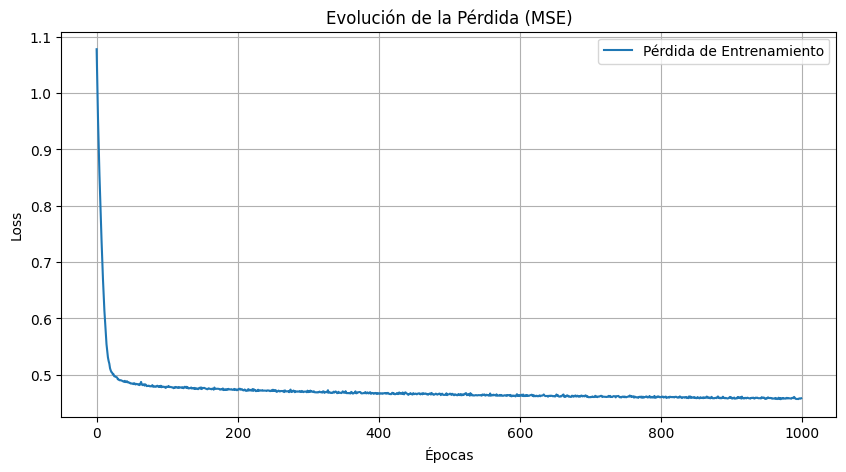

In [19]:
plt.figure(figsize=(10, 5))
plt.plot(history_loss, label='Pérdida de Entrenamiento')
plt.title('Evolución de la Pérdida (MSE)')
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

In [20]:
model.load_state_dict(torch.load("mejor_modelo.pt"))
model.eval()

Sequential(
  (0): Linear(in_features=10, out_features=32, bias=True)
  (1): ReLU()
  (2): Linear(in_features=32, out_features=1, bias=True)
)

In [21]:
model.eval()
preds = []
reales = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        y_pred = model(X_batch).squeeze()
        preds.extend(y_pred.numpy())
        reales.extend(y_batch.numpy())

In [22]:
preds_real = np.array(preds) * y_std + y_mean
reales_real = np.array(reales) * y_std + y_mean

r2 = r2_score(reales_real, preds_real)
print("R2:", r2)

R2: 0.5181546781162292


In [23]:
y_preds = []
y_reales = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        pred = model(X_batch)
        y_preds.append(pred.numpy())
        y_reales.append(y_batch.numpy())

y_preds = np.vstack(y_preds)
y_reales = np.vstack(y_reales)

In [24]:
perfil_nuevo = np.array([5, 46.9, 3.56, 44.6, 61, 7.09, 97.98, 13, 7, 0.59])

# Normalizar (igual que antes)
perfil_norm = (perfil_nuevo - X_mean) / X_std

# Convertir a tensor
perfil_tensor = torch.tensor(perfil_norm, dtype=torch.float32).unsqueeze(0)

with torch.no_grad():
    pred = model(perfil_tensor)

# 🔥 desnormalizar
pred_real = pred.item() * y_std + y_mean

print(f"Salario estimado: {pred_real:.2f}")

Salario estimado: 85707.07


In [25]:
pred_real = pred.item() * y_std + y_mean
real = y_test[0] * y_std + y_mean

print("Predicción:", pred_real)
print("Real:", real)

Predicción: 85707.0696623063
Real: 130537.0


In [26]:
for i in range(10):
    print(f"Real: {y_reales[i][0]:.2f} | Pred: {y_preds[i][0]:.2f}")

Real: 0.78 | Pred: 0.01
Real: -0.50 | Pred: -1.12
Real: -0.98 | Pred: -0.87
Real: 2.01 | Pred: 1.08
Real: -1.47 | Pred: -0.40
Real: -0.78 | Pred: 1.55
Real: -0.26 | Pred: -0.06
Real: -0.87 | Pred: -0.85
Real: -0.35 | Pred: -0.44
Real: -0.47 | Pred: -0.78
